# Loan Default / Credit Risk Prediction — Logistic Regression Model

**Business problem:** Predict whether a loan applicant is likely to default, so the lender can make better approval and pricing decisions.

**Approach:** Binary classification using Logistic Regression (a standard, interpretable model for credit risk scoring in the finance industry).

**Note on the data:** This notebook uses a *synthetic* (artificially generated but realistically structured) dataset, since real customer credit data is private and not available to us. The features below (income, credit score, debt-to-income ratio, etc.) are the same kind of fields a real bank/NBFC dataset would contain. The workflow, model, and evaluation approach here is exactly what would be used on real data.


## 1. Install & import libraries

Run this cell first in Google Colab (the `!pip install` line is a no-op if packages are already present).

In [21]:
!pip install -q numpy pandas matplotlib seaborn scikit-learn

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score, confusion_matrix, classification_report,
    roc_auc_score, roc_curve
)

np.random.seed(42)
sns.set_style("whitegrid")


## 2. Generate the dataset

Features used (typical of a credit risk / loan application dataset):
- **age** — applicant age
- **annual_income** — annual income (in ₹ thousands)
- **credit_score** — credit bureau score (300–900, CIBIL-style)
- **loan_amount** — amount requested (in ₹ thousands)
- **loan_term_months** — repayment period
- **employment_length_years** — years in current job
- **debt_to_income** — existing debt as a ratio of income
- **previous_defaults** — number of past missed/defaulted payments

**Target:** `default` (1 = defaulted, 0 = repaid normally)


In [22]:
n = 2000

age = np.random.randint(21, 65, n)
annual_income = np.random.normal(600, 250, n).clip(120, 3000)          # in ₹ thousands
credit_score = np.random.normal(680, 90, n).clip(300, 900)
loan_amount = np.random.normal(400, 200, n).clip(20, 2000)             # in ₹ thousands
loan_term_months = np.random.choice([12, 24, 36, 48, 60], n)
employment_length_years = np.random.exponential(5, n).clip(0, 35)
debt_to_income = np.random.normal(0.35, 0.15, n).clip(0.01, 1.2)
previous_defaults = np.random.poisson(0.4, n).clip(0, 5)

# Build a "true" risk score so the target is logically related to the features
# (lower credit score, higher DTI, more previous defaults, smaller income -> higher risk)
risk_score = (
    -0.015 * (credit_score - 680)
    + 3.2 * (debt_to_income - 0.35)
    + 0.9 * previous_defaults
    - 0.0009 * (annual_income - 600)
    + 0.004 * (loan_amount - 400)
    - 0.03 * (employment_length_years - 5)
    + np.random.normal(0, 1, n)   # noise
)

prob_default = 1 / (1 + np.exp(-risk_score))
default = (np.random.rand(n) < prob_default).astype(int)

df = pd.DataFrame({
    "age": age.round(0),
    "annual_income_k": annual_income.round(1),
    "credit_score": credit_score.round(0),
    "loan_amount_k": loan_amount.round(1),
    "loan_term_months": loan_term_months,
    "employment_length_years": employment_length_years.round(1),
    "debt_to_income": debt_to_income.round(2),
    "previous_defaults": previous_defaults,
    "default": default
})

print("Default rate in dataset:", round(df['default'].mean() * 100, 1), "%")
df.head()


Default rate in dataset: 53.4 %


,age,annual_income_k,credit_score,loan_amount_k,loan_term_months,employment_length_years,debt_to_income,previous_defaults,default
0,59,922.4,741.0,517.7,12,5.3,0.34,0,0
1,49,534.7,467.0,533.4,60,1.5,0.16,0,1
2,35,630.1,703.0,332.6,48,0.4,0.42,0,1
3,63,342.8,573.0,427.6,24,2.7,0.15,0,1
4,28,280.5,735.0,504.1,12,3.1,0.04,0,0


## 3. Quick exploratory check

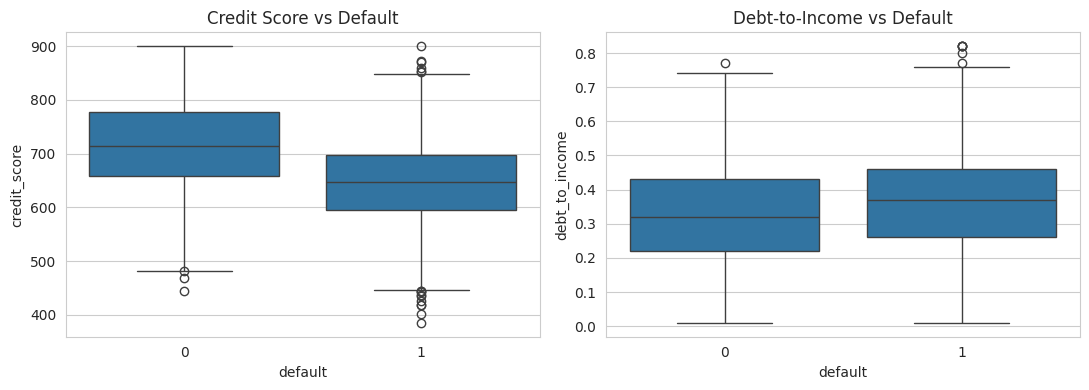

In [23]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

sns.boxplot(x="default", y="credit_score", data=df, ax=axes[0])
axes[0].set_title("Credit Score vs Default")

sns.boxplot(x="default", y="debt_to_income", data=df, ax=axes[1])
axes[1].set_title("Debt-to-Income vs Default")

plt.tight_layout()
plt.show()


## 4. Train / test split and scaling

In [24]:
feature_cols = [
    "age", "annual_income_k", "credit_score", "loan_amount_k",
    "loan_term_months", "employment_length_years",
    "debt_to_income", "previous_defaults"
]

X = df[feature_cols]
y = df["default"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42, stratify=y
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Train size:", X_train.shape, " Test size:", X_test.shape)


Train size: (1500, 8)  Test size: (500, 8)


## 5. Train the Logistic Regression model

In [25]:
model = LogisticRegression(max_iter=1000)
model.fit(X_train_scaled, y_train)

y_pred = model.predict(X_test_scaled)
y_proba = model.predict_proba(X_test_scaled)[:, 1]


## 6. Evaluate the model

Accuracy: 0.698
ROC-AUC: 0.769

Classification report:
               precision    recall  f1-score   support

           0       0.70      0.61      0.65       233
           1       0.70      0.77      0.73       267

    accuracy                           0.70       500
   macro avg       0.70      0.69      0.69       500
weighted avg       0.70      0.70      0.70       500



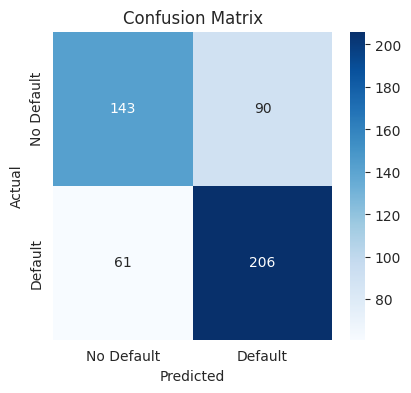

In [26]:
acc = accuracy_score(y_test, y_pred)
auc = roc_auc_score(y_test, y_proba)

print(f"Accuracy: {acc:.3f}")
print(f"ROC-AUC: {auc:.3f}\n")
print("Classification report:\n", classification_report(y_test, y_pred))

cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(4.5, 4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["No Default", "Default"],
            yticklabels=["No Default", "Default"])
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()


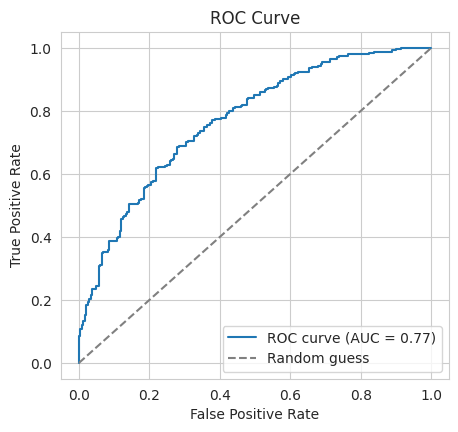

In [27]:
fpr, tpr, _ = roc_curve(y_test, y_proba)
plt.figure(figsize=(5, 4.5))
plt.plot(fpr, tpr, label=f"ROC curve (AUC = {auc:.2f})")
plt.plot([0, 1], [0, 1], linestyle="--", color="gray", label="Random guess")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()


## 7. Which features matter most?

In logistic regression, the coefficients tell us the direction and strength of each feature's effect on default risk (after scaling, so they're comparable).


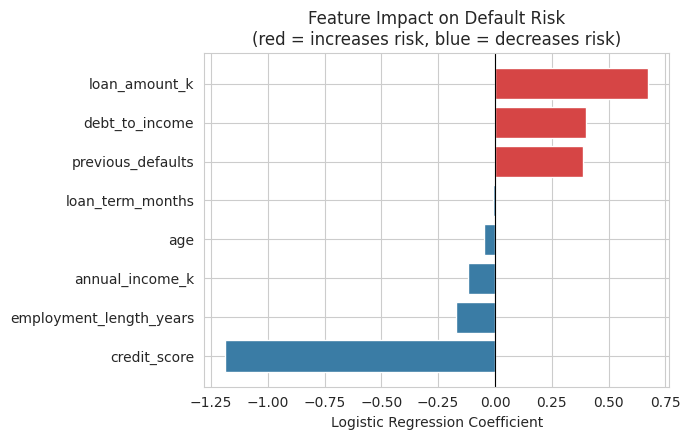

,feature,coefficient
3,loan_amount_k,0.674382
6,debt_to_income,0.398597
7,previous_defaults,0.388397
4,loan_term_months,-0.006420
0,age,-0.046837
1,annual_income_k,-0.119770
5,employment_length_years,-0.169267
2,credit_score,-1.187589


In [28]:
coef_df = pd.DataFrame({
    "feature": feature_cols,
    "coefficient": model.coef_[0]
}).sort_values("coefficient")

plt.figure(figsize=(7, 4.5))
colors = ["#d64545" if c > 0 else "#3a7ca5" for c in coef_df["coefficient"]]
plt.barh(coef_df["feature"], coef_df["coefficient"], color=colors)
plt.axvline(0, color="black", linewidth=0.8)
plt.title("Feature Impact on Default Risk\n(red = increases risk, blue = decreases risk)")
plt.xlabel("Logistic Regression Coefficient")
plt.tight_layout()
plt.show()

coef_df.sort_values("coefficient", ascending=False)


## 8. Try it on a new loan applicant

In [29]:
new_applicant = pd.DataFrame([{
    "age": 29,
    "annual_income_k": 420,
    "credit_score": 610,
    "loan_amount_k": 350,
    "loan_term_months": 36,
    "employment_length_years": 2.5,
    "debt_to_income": 0.55,
    "previous_defaults": 1
}])

new_scaled = scaler.transform(new_applicant[feature_cols])
pred = model.predict(new_scaled)[0]
proba = model.predict_proba(new_scaled)[0, 1]

print("Predicted class:", "DEFAULT RISK" if pred == 1 else "LIKELY TO REPAY")
print(f"Estimated probability of default: {proba*100:.1f}%")


Predicted class: DEFAULT RISK
Estimated probability of default: 89.6%


## 8b. Interactive demo (live sliders — Colab-friendly)

Move the sliders below to enter a hypothetical applicant's details. The prediction updates automatically — no code editing needed.

> If the sliders don't render, run `!pip install -q ipywidgets` in a cell above and re-run this cell.


In [30]:
import ipywidgets as widgets
from IPython.display import display, clear_output

age_w = widgets.IntSlider(value=29, min=21, max=65, description="Age")
income_w = widgets.IntSlider(value=420, min=120, max=3000, step=10, description="Income (₹k)")
credit_w = widgets.IntSlider(value=610, min=300, max=900, step=5, description="Credit score")
loan_amt_w = widgets.IntSlider(value=350, min=20, max=2000, step=10, description="Loan (₹k)")
term_w = widgets.Dropdown(value=36, options=[12, 24, 36, 48, 60], description="Term (months)")
emp_w = widgets.FloatSlider(value=2.5, min=0, max=35, step=0.5, description="Employment (yrs)")
dti_w = widgets.FloatSlider(value=0.55, min=0.01, max=1.2, step=0.01, description="DTI ratio")
prev_def_w = widgets.IntSlider(value=1, min=0, max=5, description="Prev. defaults")

output = widgets.Output()

def predict_from_widgets(change=None):
    with output:
        clear_output(wait=True)
        applicant = pd.DataFrame([{
            "age": age_w.value,
            "annual_income_k": income_w.value,
            "credit_score": credit_w.value,
            "loan_amount_k": loan_amt_w.value,
            "loan_term_months": term_w.value,
            "employment_length_years": emp_w.value,
            "debt_to_income": dti_w.value,
            "previous_defaults": prev_def_w.value
        }])
        scaled = scaler.transform(applicant[feature_cols])
        pred = model.predict(scaled)[0]
        proba = model.predict_proba(scaled)[0, 1]

        label = "🔴 DEFAULT RISK" if pred == 1 else "🟢 LIKELY TO REPAY"
        print(f"Prediction: {label}")
        print(f"Estimated probability of default: {proba*100:.1f}%")

all_widgets = [age_w, income_w, credit_w, loan_amt_w, term_w, emp_w, dti_w, prev_def_w]
for w in all_widgets:
    w.observe(predict_from_widgets, names="value")

display(widgets.VBox(all_widgets), output)
predict_from_widgets()  # initial run


Output()

## 9. Summary

- **Business data → AI/ML system → Prediction → Business action → Business outcome:**
  Applicant data (income, credit score, DTI, etc.) → Logistic Regression model → Default probability score → Loan officer approves/rejects or adjusts interest rate → Fewer bad loans, better-priced risk.
- **Why Logistic Regression:** it's fast, interpretable (the bank can explain *why* an application was flagged, which matters for fairness and regulation), and is an industry-standard baseline for credit scoring.
- **Responsible AI note:** a real deployment would need bias testing across demographic groups, human review of borderline/high-value cases, transparency to the applicant, and regular retraining as the market changes — this model must support the loan officer's decision, not fully replace it.

